# Logistic Regression

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/ml-mastery/blob/main/02_ml_concepts/logistic_regression.ipynb)

---

## Table of Contents
1. [Concept Overview](#1-concept-overview)
2. [Math Intuition](#2-math-intuition)
   - 2.1 Why not Linear Regression for classification?
   - 2.2 The Sigmoid Function
   - 2.3 Probabilistic Interpretation
   - 2.4 Decision Boundary
   - 2.5 Cost Function — Log Loss (Cross-Entropy)
   - 2.6 Why not MSE for classification?
   - 2.7 Gradient Derivation — step by step
   - 2.8 Multiclass — Softmax and OvR
3. [Visual Intuition](#3-visual-intuition)
4. [Code from Scratch](#4-code-from-scratch)
5. [Sklearn Implementation](#5-sklearn-implementation)
6. [Model Evaluation for Classification](#6-model-evaluation-for-classification)
7. [Common Mistakes](#7-common-mistakes)
8. [Exercises](#8-exercises)


## 1. Concept Overview

Logistic Regression is a **classification** algorithm — despite its name, it does not do regression.
It predicts the **probability** that an input belongs to a given class, then applies a threshold to make a binary decision.

**When to use it:**
- Binary classification (spam/not spam, fraud/not fraud, disease/no disease)
- When you need probability estimates, not just a label
- As a strong, interpretable baseline before trying complex models
- When the decision boundary is roughly linear

**Key idea:** Instead of fitting a line to the outputs directly (like linear regression), logistic regression fits a line to the **log-odds** of the output, which naturally keeps predictions between 0 and 1.


## 2. Math Intuition

### 2.1 Why not Linear Regression for Classification?

Linear regression predicts $\hat{y} = \mathbf{w}^T \mathbf{x}$, which can produce any value from $-\infty$ to $+\infty$.

For binary classification we need $\hat{y} \in [0, 1]$ — a probability.
Using linear regression directly causes two problems:
- Predictions go outside $[0, 1]$, making them uninterpretable as probabilities
- A single outlier can tilt the decision boundary badly

We need a function that **squashes** any real number into $(0, 1)$.

---

### 2.2 The Sigmoid Function

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Properties:
- Output is always in $(0, 1)$ — interpretable as a probability
- $\sigma(0) = 0.5$ — at $z=0$ the model is maximally uncertain
- $\sigma(z) \to 1$ as $z \to +\infty$
- $\sigma(z) \to 0$ as $z \to -\infty$
- Derivative: $\sigma'(z) = \sigma(z)(1 - \sigma(z))$ — elegant and used in the gradient derivation

The model becomes:

$$\hat{y} = \sigma(\mathbf{w}^T \mathbf{x}) = \frac{1}{1 + e^{-\mathbf{w}^T \mathbf{x}}}$$

---

### 2.3 Probabilistic Interpretation

We interpret the output as:

$$P(y=1 \mid \mathbf{x}; \mathbf{w}) = \hat{y} = \sigma(\mathbf{w}^T \mathbf{x})$$

$$P(y=0 \mid \mathbf{x}; \mathbf{w}) = 1 - \hat{y}$$

These two can be written compactly as:

$$P(y \mid \mathbf{x}; \mathbf{w}) = \hat{y}^y (1 - \hat{y})^{1-y}$$

This is the **Bernoulli likelihood** — the foundation for deriving the cost function.

---

### 2.4 Decision Boundary

We classify as class 1 if $\hat{y} \geq 0.5$, which happens when $\sigma(z) \geq 0.5$, which happens when $z \geq 0$:

$$\mathbf{w}^T \mathbf{x} \geq 0 \implies \text{class 1}$$

The **decision boundary** is the hyperplane $\mathbf{w}^T \mathbf{x} = 0$.

For 2 features: $w_0 + w_1 x_1 + w_2 x_2 = 0$, which is a line in 2D space.

With polynomial features ($x_1^2$, $x_2^2$, $x_1 x_2$, ...) the boundary becomes a curve — logistic regression can model non-linear boundaries this way.

---

### 2.5 Cost Function — Log Loss (Binary Cross-Entropy)

We derive the cost function using **Maximum Likelihood Estimation (MLE)**.

**Step 1 — Likelihood of all $m$ training examples** (assuming independence):

$$L(\mathbf{w}) = \prod_{i=1}^{m} \hat{y}^{(i)^{y^{(i)}}} (1 - \hat{y}^{(i)})^{1 - y^{(i)}}$$

**Step 2 — Log-likelihood** (log turns products into sums, easier to optimize):

$$\log L(\mathbf{w}) = \sum_{i=1}^{m} \left[ y^{(i)} \log \hat{y}^{(i)} + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

**Step 3 — Negate and average** (maximizing log-likelihood = minimizing negative log-likelihood):

$$\boxed{J(\mathbf{w}) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log \hat{y}^{(i)} + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]}$$

This is **Binary Cross-Entropy** (also called Log Loss).

**Intuition for the two terms:**
- When $y=1$: cost $= -\log(\hat{y})$ — penalizes heavily if $\hat{y}$ is near 0 (confident wrong prediction)
- When $y=0$: cost $= -\log(1 - \hat{y})$ — penalizes heavily if $\hat{y}$ is near 1

---

### 2.6 Why not MSE for Classification?

If we use MSE with sigmoid, the cost function becomes **non-convex** — full of local minima. Gradient descent cannot reliably find the global minimum.

Log Loss is **convex** with sigmoid — gradient descent is guaranteed to find the global minimum.

---

### 2.7 Gradient Derivation — Step by Step

**Goal:** compute $\frac{\partial J}{\partial \mathbf{w}}$

**Step 1 — Gradient of cost w.r.t. $\hat{y}^{(i)}$:**

$$\frac{\partial J}{\partial \hat{y}} = -\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}}$$

**Step 2 — Gradient of sigmoid w.r.t. $z = \mathbf{w}^T \mathbf{x}$:**

$$\frac{\partial \hat{y}}{\partial z} = \sigma(z)(1 - \sigma(z)) = \hat{y}(1 - \hat{y})$$

**Step 3 — Chain rule:**

$$\frac{\partial J}{\partial z} = \frac{\partial J}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} = \left(-\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}}\right) \cdot \hat{y}(1-\hat{y})$$

Expanding and simplifying (the $\hat{y}$ terms cancel beautifully):

$$\frac{\partial J}{\partial z} = \hat{y} - y$$

**Step 4 — Gradient w.r.t. weights (chain rule again, $z = \mathbf{w}^T \mathbf{x}$):**

$$\boxed{\frac{\partial J}{\partial \mathbf{w}} = \frac{1}{m} X^T (\hat{y} - y)}$$

This has the **exact same form as linear regression's gradient** — just with $\hat{y} = \sigma(X\mathbf{w})$ instead of $\hat{y} = X\mathbf{w}$.

**Update rule:**

$$\mathbf{w} := \mathbf{w} - \frac{\alpha}{m} X^T(\hat{y} - y)$$

---

### 2.8 Multiclass — Softmax and One-vs-Rest

**One-vs-Rest (OvR):** Train $K$ binary classifiers, one per class. Predict the class whose classifier gives the highest probability. Simple and works well in practice.

**Softmax (Multinomial Logistic Regression):** A true multiclass extension of sigmoid.

$$P(y = k \mid \mathbf{x}) = \frac{e^{\mathbf{w}_k^T \mathbf{x}}}{\sum_{j=1}^{K} e^{\mathbf{w}_j^T \mathbf{x}}}$$

Properties:
- All class probabilities sum to 1
- Reduces to sigmoid for $K=2$
- Cost function becomes categorical cross-entropy


## 3. Visual Intuition

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)


/tmp/ipykernel_7696/1943424413.py:37: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_7696/1943424413.py:37: UserWarning: Glyph 7611 (\N{MODIFIER LETTER SMALL Z}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7611 (\N{MODIFIER LETTER SMALL Z}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


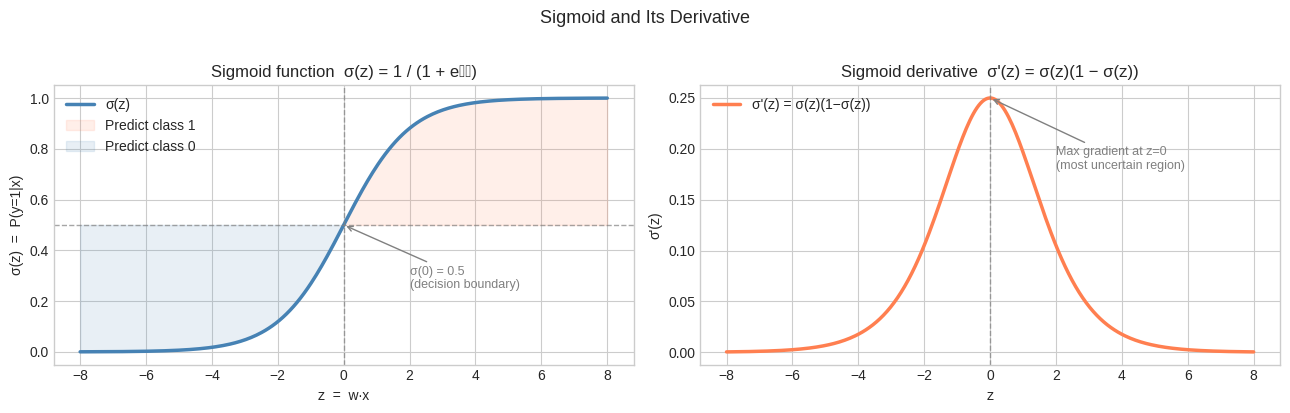

In [20]:
# ── Plot 1: Sigmoid function and its derivative ──────────────────────────────
z = np.linspace(-8, 8, 300)
sigmoid = 1 / (1 + np.exp(-z))
sigmoid_der = sigmoid * (1 - sigmoid)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sigmoid
axes[0].plot(z, sigmoid, color='steelblue', linewidth=2.5, label='σ(z)')
axes[0].axhline(0.5, color='gray', linewidth=1, linestyle='--', alpha=0.7)
axes[0].axvline(0.0, color='gray', linewidth=1, linestyle='--', alpha=0.7)
axes[0].fill_between(z, sigmoid, 0.5, where=(z >= 0), alpha=0.12, color='coral', label='Predict class 1')
axes[0].fill_between(z, sigmoid, 0.5, where=(z <= 0), alpha=0.12, color='steelblue', label='Predict class 0')
axes[0].set_title("Sigmoid function  σ(z) = 1 / (1 + e⁻ᶻ)", fontsize=12)
axes[0].set_xlabel("z  =  w·x")
axes[0].set_ylabel("σ(z)  =  P(y=1|x)")
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend()

# Annotations
axes[0].annotate('σ(0) = 0.5\n(decision boundary)', xy=(0, 0.5),
                 xytext=(2, 0.25), fontsize=9, color='gray',
                 arrowprops=dict(arrowstyle='->', color='gray'))

# Derivative
axes[1].plot(z, sigmoid_der, color='coral', linewidth=2.5, label="σ'(z) = σ(z)(1−σ(z))")
axes[1].axvline(0.0, color='gray', linewidth=1, linestyle='--', alpha=0.7)
axes[1].set_title("Sigmoid derivative  σ'(z) = σ(z)(1 − σ(z))", fontsize=12)
axes[1].set_xlabel("z")
axes[1].set_ylabel("σ'(z)")
axes[1].legend()
axes[1].annotate('Max gradient at z=0\n(most uncertain region)', xy=(0, 0.25),
                 xytext=(2, 0.18), fontsize=9, color='gray',
                 arrowprops=dict(arrowstyle='->', color='gray'))

plt.suptitle("Sigmoid and Its Derivative", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


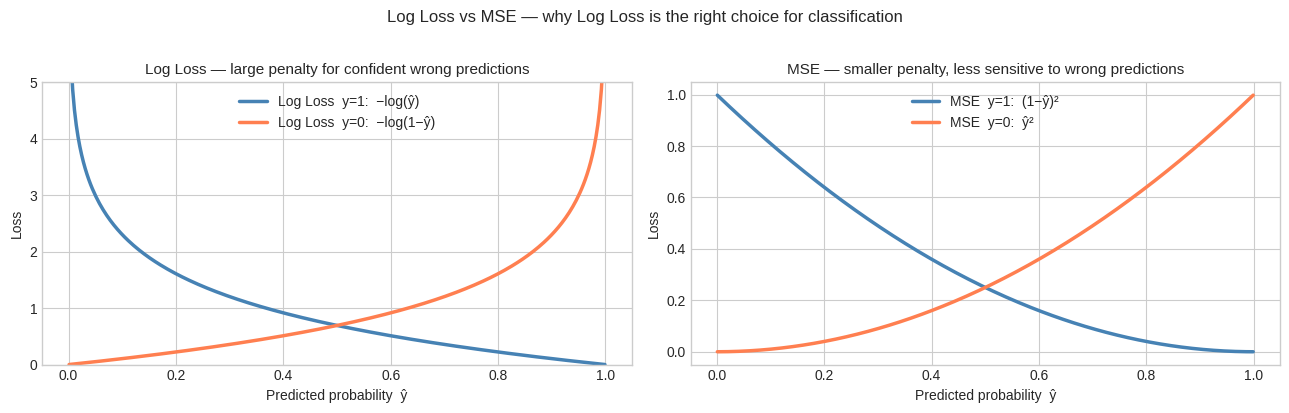

In [21]:
# ── Plot 2: Log Loss vs MSE — convex vs non-convex ───────────────────────────
y_hat = np.linspace(0.001, 0.999, 300)

log_loss_y1  = -np.log(y_hat)           # when y=1
log_loss_y0  = -np.log(1 - y_hat)       # when y=0
mse_y1       = (1 - y_hat)**2
mse_y0       = y_hat**2

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(y_hat, log_loss_y1, color='steelblue', linewidth=2.5, label='Log Loss  y=1:  −log(ŷ)')
axes[0].plot(y_hat, log_loss_y0, color='coral',     linewidth=2.5, label='Log Loss  y=0:  −log(1−ŷ)')
axes[0].set_title("Log Loss — large penalty for confident wrong predictions", fontsize=11)
axes[0].set_xlabel("Predicted probability  ŷ")
axes[0].set_ylabel("Loss")
axes[0].set_ylim(0, 5)
axes[0].legend()

axes[1].plot(y_hat, mse_y1, color='steelblue', linewidth=2.5, label='MSE  y=1:  (1−ŷ)²')
axes[1].plot(y_hat, mse_y0, color='coral',     linewidth=2.5, label='MSE  y=0:  ŷ²')
axes[1].set_title("MSE — smaller penalty, less sensitive to wrong predictions", fontsize=11)
axes[1].set_xlabel("Predicted probability  ŷ")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.suptitle("Log Loss vs MSE — why Log Loss is the right choice for classification", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


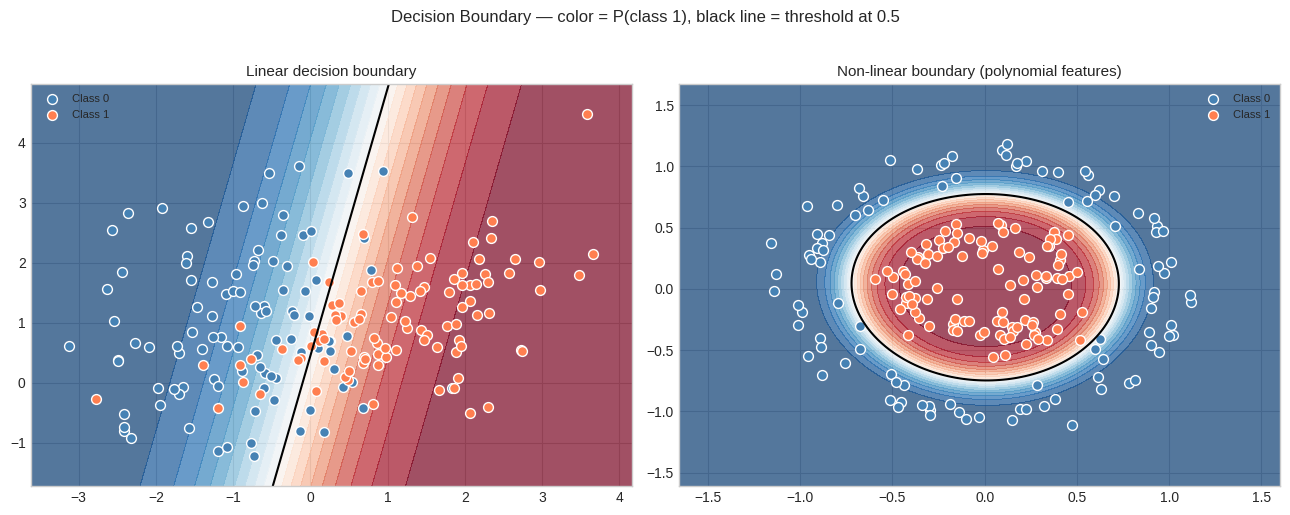

In [22]:
# ── Plot 3: Decision boundary in 2D ─────────────────────────────────────────
from sklearn.datasets import make_classification, make_circles
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

def plot_decision_boundary(model, X, y, ax, title):
    h = 0.02
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.7)
    ax.contour( xx, yy, Z, levels=[0.5], colors='black', linewidths=1.5)
    ax.scatter(X[y==0,0], X[y==0,1], c='steelblue', edgecolors='white', s=50, label='Class 0')
    ax.scatter(X[y==1,0], X[y==1,1], c='coral',     edgecolors='white', s=50, label='Class 1')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)

# Dataset 1: linearly separable
X_lin, y_lin = make_classification(n_samples=200, n_features=2, n_redundant=0,
                                    n_informative=2, random_state=42, n_clusters_per_class=1)
# Dataset 2: circular (non-linear)
X_circ, y_circ = make_circles(n_samples=200, noise=0.1, factor=0.4, random_state=42)

# Linear boundary
model_lin = Pipeline([('sc', StandardScaler()), ('lr', LogisticRegression())])
model_lin.fit(X_lin, y_lin)

# Non-linear boundary using polynomial features
model_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('sc',   StandardScaler()),
    ('lr',   LogisticRegression(C=1.0))
])
model_poly.fit(X_circ, y_circ)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_decision_boundary(model_lin,  X_lin,  y_lin,  axes[0], "Linear decision boundary")
plot_decision_boundary(model_poly, X_circ, y_circ, axes[1], "Non-linear boundary (polynomial features)")

plt.suptitle("Decision Boundary — color = P(class 1), black line = threshold at 0.5", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 4. Code from Scratch

In [23]:
class LogisticRegressionScratch:
    """
    Binary Logistic Regression using Gradient Descent.

    Model:        ŷ = σ(Xw)  where σ(z) = 1 / (1 + exp(-z))
    Cost:         J = -(1/m) * Σ [ y*log(ŷ) + (1-y)*log(1-ŷ) ]
    Gradient:     ∂J/∂w = (1/m) * X^T * (ŷ - y)
    Update:       w := w - α * ∂J/∂w
    """

    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.lr           = learning_rate
        self.n_iterations = n_iterations
        self.weights      = None
        self.cost_history = []

    @staticmethod
    def _sigmoid(z):
        # Clip z to avoid overflow in exp
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def _add_bias(self, X):
        return np.hstack([np.ones((X.shape[0], 1)), X])

    def fit(self, X, y):
        X_b = self._add_bias(X)
        m, n = X_b.shape
        self.weights = np.zeros(n)

        for _ in range(self.n_iterations):
            z      = X_b @ self.weights              # (m,)
            y_hat  = self._sigmoid(z)                # (m,)
            error  = y_hat - y                       # (m,)
            grad   = (X_b.T @ error) / m             # (n+1,)
            self.weights -= self.lr * grad

            # Log loss
            eps  = 1e-15   # avoid log(0)
            cost = -np.mean(y * np.log(y_hat + eps) + (1-y) * np.log(1 - y_hat + eps))
            self.cost_history.append(cost)

        return self

    def predict_proba(self, X):
        """Returns P(y=1 | x) for each sample."""
        X_b = self._add_bias(X)
        return self._sigmoid(X_b @ self.weights)

    def predict(self, X, threshold=0.5):
        """Returns class labels (0 or 1)."""
        return (self.predict_proba(X) >= threshold).astype(int)

    def score(self, X, y):
        """Accuracy."""
        return np.mean(self.predict(X) == y)


Train accuracy: 0.9050
Test  accuracy: 0.9100


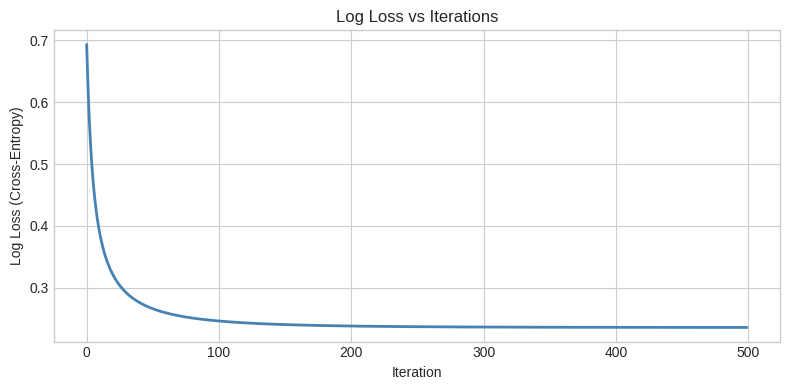

In [24]:
# ── Generate a binary classification dataset ────────────────────────────────
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_classification(
    n_samples=500, n_features=2, n_redundant=0,
    n_informative=2, random_state=42, n_clusters_per_class=1,
    class_sep=1.2
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Train
model_scratch = LogisticRegressionScratch(learning_rate=0.5, n_iterations=500)
model_scratch.fit(X_train_s, y_train)

print(f"Train accuracy: {model_scratch.score(X_train_s, y_train):.4f}")
print(f"Test  accuracy: {model_scratch.score(X_test_s,  y_test):.4f}")

# Cost curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(model_scratch.cost_history, color='steelblue', linewidth=2)
ax.set_title("Log Loss vs Iterations")
ax.set_xlabel("Iteration")
ax.set_ylabel("Log Loss (Cross-Entropy)")
plt.tight_layout()
plt.show()


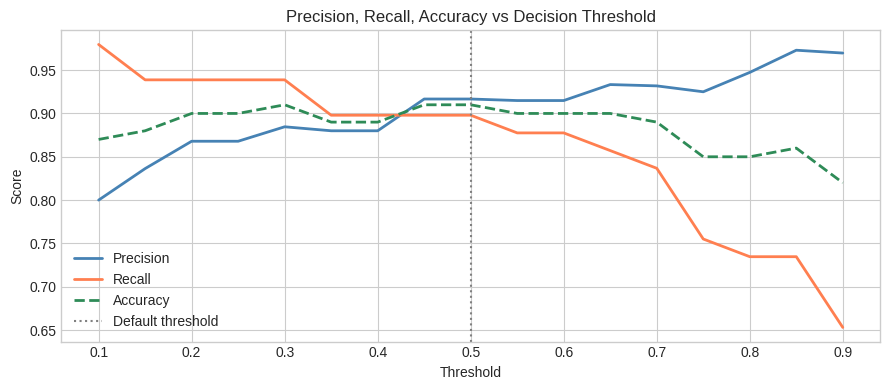

In [25]:
# ── Effect of decision threshold ────────────────────────────────────────────
# The default threshold is 0.5 but you can tune it.
# Lowering threshold → more positives predicted (higher recall, lower precision)
# Raising threshold  → fewer positives predicted (lower recall, higher precision)

probs = model_scratch.predict_proba(X_test_s)

thresholds  = np.arange(0.1, 0.91, 0.05)
precisions, recalls, accuracies = [], [], []

for t in thresholds:
    preds = (probs >= t).astype(int)
    tp = np.sum((preds == 1) & (y_test == 1))
    fp = np.sum((preds == 1) & (y_test == 0))
    fn = np.sum((preds == 0) & (y_test == 1))
    precision  = tp / (tp + fp + 1e-9)
    recall     = tp / (tp + fn + 1e-9)
    accuracy   = np.mean(preds == y_test)
    precisions.append(precision)
    recalls.append(recall)
    accuracies.append(accuracy)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, precisions,  color='steelblue', linewidth=2, label='Precision')
ax.plot(thresholds, recalls,     color='coral',     linewidth=2, label='Recall')
ax.plot(thresholds, accuracies,  color='seagreen',  linewidth=2, label='Accuracy', linestyle='--')
ax.axvline(0.5, color='gray', linestyle=':', linewidth=1.5, label='Default threshold')
ax.set_title("Precision, Recall, Accuracy vs Decision Threshold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Sklearn Implementation

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
        C=1.0,              # regularization strength (1/lambda) — smaller C = stronger reg
        penalty='l2',       # 'l1', 'l2', 'elasticnet', None
        solver='lbfgs',     # 'lbfgs' for small data, 'saga' for large/sparse
        max_iter=1000,
        random_state=42
    ))
])

pipe.fit(X_train, y_train)

print("Sklearn LogisticRegression:")
print(f"  Intercept:    {pipe.named_steps['model'].intercept_[0]:.4f}")
print(f"  Coefficients: {pipe.named_steps['model'].coef_[0]}")
print(f"  Train acc:    {pipe.score(X_train, y_train):.4f}")
print(f"  Test  acc:    {pipe.score(X_test,  y_test):.4f}")

cv = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
print(f"\n5-Fold CV Accuracy: {cv.mean():.4f} ± {cv.std():.4f}")


Sklearn LogisticRegression:
  Intercept:    -0.3935
  Coefficients: [0.43995719 3.8249318 ]
  Train acc:    0.9050
  Test  acc:    0.9100

5-Fold CV Accuracy: 0.9040 ± 0.0162


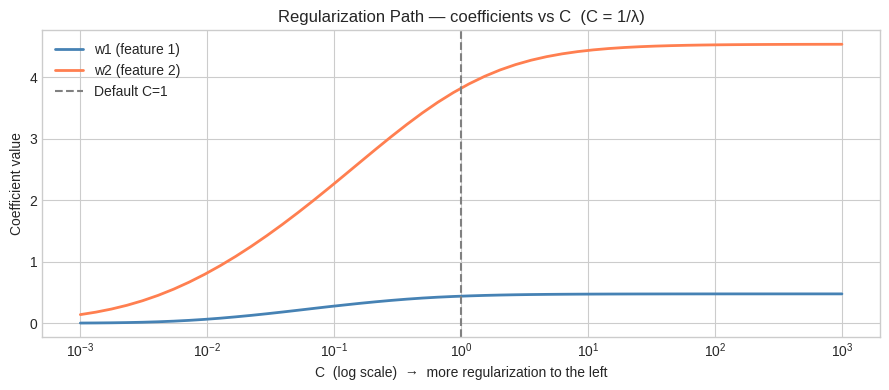

In [27]:
# Regularization path — how C affects coefficients
Cs      = np.logspace(-3, 3, 50)
coef_0s = []
coef_1s = []

for C in Cs:
    m_c = Pipeline([
        ('sc', StandardScaler()),
        ('lr', LogisticRegression(C=C, max_iter=1000, random_state=42))
    ])
    m_c.fit(X_train, y_train)
    coef_0s.append(m_c.named_steps['lr'].coef_[0][0])
    coef_1s.append(m_c.named_steps['lr'].coef_[0][1])

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(Cs, coef_0s, color='steelblue', linewidth=2, label='w1 (feature 1)')
ax.semilogx(Cs, coef_1s, color='coral',     linewidth=2, label='w2 (feature 2)')
ax.axvline(1.0, color='gray', linestyle='--', linewidth=1.5, label='Default C=1')
ax.set_title("Regularization Path — coefficients vs C  (C = 1/λ)")
ax.set_xlabel("C  (log scale)  →  more regularization to the left")
ax.set_ylabel("Coefficient value")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Model Evaluation for Classification

Accuracy alone is not enough — especially on imbalanced datasets. You need the full picture.

| Metric | Formula | Use when |
|---|---|---|
| **Accuracy** | $(TP+TN)/(TP+TN+FP+FN)$ | Classes are balanced |
| **Precision** | $TP/(TP+FP)$ | False positives are costly (spam filter) |
| **Recall** | $TP/(TP+FN)$ | False negatives are costly (cancer screening) |
| **F1 Score** | $2 \cdot \frac{P \cdot R}{P+R}$ | Balance between precision and recall |
| **AUC-ROC** | Area under ROC curve | Overall ranking ability, imbalanced data |
| **Log Loss** | Cross-entropy | When you care about probability calibration |


In [28]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, precision_recall_curve)

y_pred       = pipe.predict(X_test)
y_pred_proba = pipe.predict_proba(X_test)[:,1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))


Classification Report:
              precision    recall  f1-score   support

     Class 0       0.90      0.92      0.91        51
     Class 1       0.92      0.90      0.91        49

    accuracy                           0.91       100
   macro avg       0.91      0.91      0.91       100
weighted avg       0.91      0.91      0.91       100



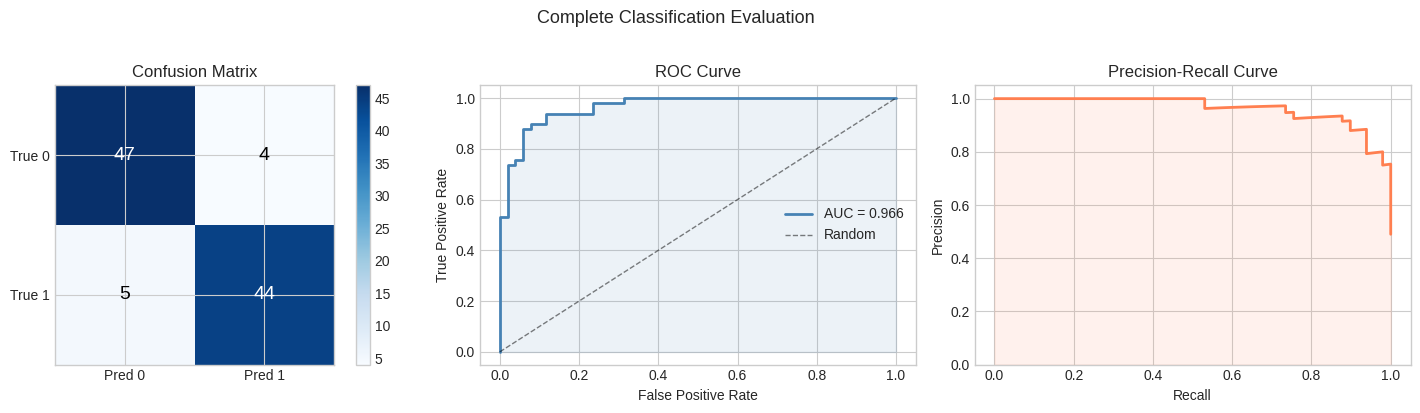

In [29]:
# Confusion matrix + ROC + Precision-Recall in one figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── 1. Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
im = axes[0].imshow(cm, cmap='Blues')
plt.colorbar(im, ax=axes[0])
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Pred 0','Pred 1'])
axes[0].set_yticklabels(['True 0','True 1'])
axes[0].set_title("Confusion Matrix")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i,j]), ha='center', va='center',
                     fontsize=14, color='white' if cm[i,j] > cm.max()/2 else 'black')

# ── 2. ROC Curve ─────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc      = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

# ── 3. Precision-Recall Curve ────────────────────────────────────────────────
prec, rec, _ = precision_recall_curve(y_test, y_pred_proba)
axes[2].plot(rec, prec, color='coral', linewidth=2)
axes[2].fill_between(rec, prec, alpha=0.1, color='coral')
axes[2].set_title("Precision-Recall Curve")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_ylim(0, 1.05)

plt.suptitle("Complete Classification Evaluation", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 7. Common Mistakes

In [30]:
# MISTAKE 1: Using accuracy on imbalanced data
rng2 = np.random.default_rng(0)
n_total   = 1000
n_positive = 50   # only 5% positive class

X_imb = rng2.normal(0, 1, (n_total, 2))
y_imb = np.zeros(n_total, dtype=int)
y_imb[:n_positive] = 1

# A model that predicts class 0 every single time
y_dummy = np.zeros(n_total, dtype=int)

print("Class distribution:", np.bincount(y_imb))
print(f"Accuracy of 'always predict 0': {np.mean(y_dummy == y_imb):.2%}")
print("That looks great — but it catches ZERO positive cases!")
print()
print("Always check precision, recall, and F1 on imbalanced data.")
print("Consider: class_weight='balanced' in LogisticRegression.")


Class distribution: [950  50]
Accuracy of 'always predict 0': 95.00%
That looks great — but it catches ZERO positive cases!

Always check precision, recall, and F1 on imbalanced data.
Consider: class_weight='balanced' in LogisticRegression.


In [31]:
# MISTAKE 2: Forgetting that C is inverse of lambda
# sklearn's C = 1/lambda (regularization strength)
# Larger C = less regularization (more complex model, risk of overfit)
# Smaller C = more regularization (simpler model, risk of underfit)

print("sklearn convention:  C = 1/lambda")
print()
print("C = 0.001  →  very strong regularization (heavily penalizes large weights)")
print("C = 1.0    →  default, moderate regularization")
print("C = 1000   →  almost no regularization (can overfit)")
print()
print("To tune C, use LogisticRegressionCV or GridSearchCV.")


sklearn convention:  C = 1/lambda

C = 0.001  →  very strong regularization (heavily penalizes large weights)
C = 1.0    →  default, moderate regularization
C = 1000   →  almost no regularization (can overfit)

To tune C, use LogisticRegressionCV or GridSearchCV.


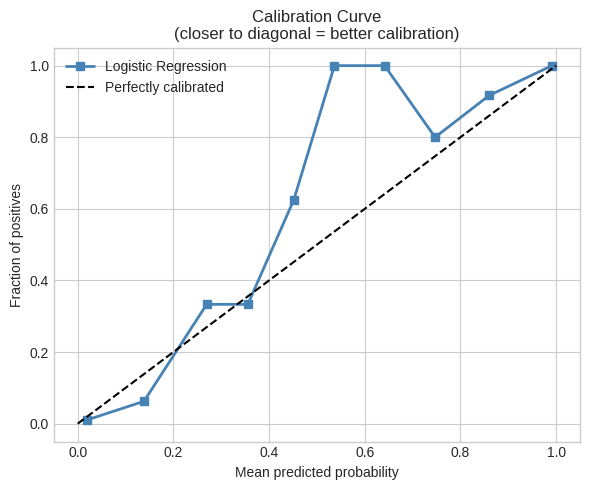

In [32]:
# MISTAKE 3: Not calibrating probabilities
# LogisticRegression can output poorly calibrated probabilities.
# For applications that need trustworthy P(y=1|x), check calibration.

from sklearn.calibration import calibration_curve

X_cal, y_cal = make_classification(n_samples=2000, n_features=5,
                                    random_state=0, class_sep=0.8)
X_tr, X_te, y_tr, y_te = train_test_split(X_cal, y_cal, test_size=0.3, random_state=0)

pipe_cal = Pipeline([('sc', StandardScaler()), ('lr', LogisticRegression())])
pipe_cal.fit(X_tr, y_tr)

prob_true, prob_pred = calibration_curve(y_te, pipe_cal.predict_proba(X_te)[:,1], n_bins=10)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(prob_pred, prob_true, 's-', color='steelblue', linewidth=2, label='Logistic Regression')
ax.plot([0,1], [0,1], 'k--', linewidth=1.5, label='Perfectly calibrated')
ax.set_title("Calibration Curve\n(closer to diagonal = better calibration)")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Exercises

**Exercise 1:** Implement the sigmoid function and manually verify the key property used in the gradient derivation:
$$\frac{d\sigma}{dz} = \sigma(z)(1 - \sigma(z))$$
Verify numerically using finite differences: $\sigma'(z) \approx \frac{\sigma(z+h) - \sigma(z-h)}{2h}$ for small $h$.


In [33]:
# Your code here


In [34]:
# Solution
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_deriv_analytic(z):
    s = sigmoid(z)
    return s * (1 - s)

def sigmoid_deriv_numerical(z, h=1e-5):
    return (sigmoid(z + h) - sigmoid(z - h)) / (2 * h)

z_vals = np.array([-3.0, -1.0, 0.0, 1.0, 3.0])
analytic  = sigmoid_deriv_analytic(z_vals)
numerical = sigmoid_deriv_numerical(z_vals)

print(f"{'z':>6}  {'Analytic':>12}  {'Numerical':>12}  {'Diff':>12}")
for z, a, n in zip(z_vals, analytic, numerical):
    print(f"{z:6.1f}  {a:12.8f}  {n:12.8f}  {abs(a-n):12.2e}")
print("\nBoth match — derivative property verified.")


     z      Analytic     Numerical          Diff
  -3.0    0.04517666    0.04517666      6.29e-13
  -1.0    0.19661193    0.19661193      1.01e-12
   0.0    0.25000000    0.25000000      6.69e-12
   1.0    0.19661193    0.19661193      1.76e-12
   3.0    0.04517666    0.04517666      1.11e-12

Both match — derivative property verified.


**Exercise 2:** Extend `LogisticRegressionScratch` to support L2 regularization.
The regularized gradient is:
$$\frac{\partial J_{reg}}{\partial \mathbf{w}} = \frac{1}{m} X^T(\hat{y} - y) + \frac{\lambda}{m} \mathbf{w}$$
Do **not** regularize the bias term. Train with $\lambda \in \{0, 0.1, 1.0, 10.0\}$ and compare test accuracies.


In [35]:
# Your code here


In [36]:
# Solution
class RegularizedLogisticRegression:
    def __init__(self, lr=0.1, n_iter=500, lambda_=0.0):
        self.lr       = lr
        self.n_iter   = n_iter
        self.lambda_  = lambda_
        self.weights  = None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        m = X.shape[0]
        X_b = np.hstack([np.ones((m,1)), X])
        self.weights = np.zeros(X_b.shape[1])

        for _ in range(self.n_iter):
            y_hat = self._sigmoid(X_b @ self.weights)
            grad  = (X_b.T @ (y_hat - y)) / m
            reg   = (self.lambda_ / m) * self.weights.copy()
            reg[0] = 0   # no penalty on bias
            self.weights -= self.lr * (grad + reg)
        return self

    def predict(self, X, thresh=0.5):
        X_b = np.hstack([np.ones((X.shape[0],1)), X])
        return (self._sigmoid(X_b @ self.weights) >= thresh).astype(int)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

print(f"{'Lambda':>8}  {'Train Acc':>10}  {'Test Acc':>10}")
for lam in [0.0, 0.1, 1.0, 10.0]:
    m = RegularizedLogisticRegression(lr=0.3, n_iter=500, lambda_=lam)
    m.fit(X_train_s, y_train)
    print(f"{lam:8.1f}  {m.score(X_train_s, y_train):10.4f}  {m.score(X_test_s, y_test):10.4f}")


  Lambda   Train Acc    Test Acc
     0.0      0.9050      0.9100
     0.1      0.9050      0.9100
     1.0      0.9050      0.9100
    10.0      0.9000      0.9100


**Exercise 3:** On an imbalanced dataset (95% class 0, 5% class 1), train a logistic regression with and without `class_weight='balanced'`. Compare precision, recall, and F1 score for both. Which one would you deploy for a medical diagnosis use case and why?


In [37]:
# Your code here


In [38]:
# Solution
from sklearn.metrics import f1_score, precision_score, recall_score

rng3 = np.random.default_rng(99)
X_ib = rng3.normal(0, 1, (1000, 4))
y_ib = (rng3.random(1000) < 0.05).astype(int)   # 5% positive

X_tr_ib, X_te_ib, y_tr_ib, y_te_ib = train_test_split(X_ib, y_ib, test_size=0.3,
                                                         random_state=42, stratify=y_ib)

results = {}
for cw in [None, 'balanced']:
    p = Pipeline([
        ('sc', StandardScaler()),
        ('lr', LogisticRegression(class_weight=cw, max_iter=1000, random_state=42))
    ])
    p.fit(X_tr_ib, y_tr_ib)
    yp = p.predict(X_te_ib)
    results[str(cw)] = {
        'Accuracy':  np.mean(yp == y_te_ib),
        'Precision': precision_score(y_te_ib, yp, zero_division=0),
        'Recall':    recall_score(y_te_ib, yp),
        'F1':        f1_score(y_te_ib, yp, zero_division=0),
    }

print(f"{'Metric':<12}  {'No weight':>12}  {'Balanced':>12}")
for metric in ['Accuracy', 'Precision', 'Recall', 'F1']:
    print(f"{metric:<12}  {results['None'][metric]:12.4f}  {results['balanced'][metric]:12.4f}")

print()
print("For medical diagnosis: use class_weight='balanced'.")
print("Missing a true positive (sick patient) is far worse than a false alarm.")
print("Balanced weights give higher recall at the cost of some precision — the right tradeoff.")


Metric           No weight      Balanced
Accuracy            0.9500        0.5633
Precision           0.0000        0.0606
Recall              0.0000        0.5333
F1                  0.0000        0.1088

For medical diagnosis: use class_weight='balanced'.
Missing a true positive (sick patient) is far worse than a false alarm.
Balanced weights give higher recall at the cost of some precision — the right tradeoff.


---

## 👨‍💻 Author

**Himanshu Kumar**

- 🌐 GitHub: [@himanshu231204](https://github.com/himanshu231204)
- 💼 LinkedIn: [himanshu231204](https://www.linkedin.com/in/himanshu231204)
- 🐦 Twitter/X: [@himanshu231204](https://twitter.com/himanshu231204)
- 📧 Email: himanshu231204@gmail.com
